# CE49X Midterm Exam - Part 2 (Coding Exercise)
## Power Grid Stability Prediction

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Date:** April 8, 2026  
**Duration:** 60 minutes  
**Total Points:** 50 (+3 bonus)

---

**Student Name:**  Ahmet Faruk Tekin
**Student ID:**  2021403150

## Background

Electrical grid stability is a critical infrastructure challenge. As cities grow and energy consumption patterns become more complex, maintaining a stable power grid requires understanding how different factors — such as reaction times of energy producers, power consumption patterns, and price sensitivity of consumers — affect overall grid stability.

In this exercise, you will work with the **UCI Electrical Grid Stability** dataset, which contains 10,000 simulated scenarios of a 4-node star power grid. The grid consists of **one energy producer** (node 1) connected to **three consumers** (nodes 2, 3, 4). Each scenario records the operating parameters of all four nodes and whether the grid remained **stable** or became **unstable**.

Your task is to explore the data, identify which factors most influence grid stability, and build a classifier to predict whether a given configuration will be stable or unstable.

> **Key Insight:** This is an infrastructure safety problem. An unstable grid can lead to blackouts, equipment damage, and cascading failures. The cost of failing to detect instability is far greater than the cost of a false alarm.

## Dataset Description

The dataset is from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/471/) (Dataset #471).

| Feature | Description | Unit |
|---------|-------------|------|
| `tau1` | Reaction time of producer (node 1) | seconds |
| `tau2` | Reaction time of consumer 2 | seconds |
| `tau3` | Reaction time of consumer 3 | seconds |
| `tau4` | Reaction time of consumer 4 | seconds |
| `p1` | Power produced by node 1 | per unit |
| `p2` | Power consumed by node 2 | per unit |
| `p3` | Power consumed by node 3 | per unit |
| `p4` | Power consumed by node 4 | per unit |
| `g1` | Price elasticity coefficient of producer | dimensionless |
| `g2` | Price elasticity coefficient of consumer 2 | dimensionless |
| `g3` | Price elasticity coefficient of consumer 3 | dimensionless |
| `g4` | Price elasticity coefficient of consumer 4 | dimensionless |
| `stab` | Stability measure (continuous) | — |
| **`stabf`** | **Stability label: `stable` or `unstable`** | **— (target)** |

- **Positive `stab`** values indicate instability; negative values indicate stability
- **Power balance:** `p1 + p2 + p3 + p4` should be close to zero (production = consumption)

## Tasks Overview

| # | Task | Points |
|---|------|--------|
| 1 | Data Loading & Exploration | 8 |
| 2 | Feature Engineering | 8 |
| 3 | Grouped Analysis | 10 |
| 4 | Visualization | 12 |
| 5 | Statistical Analysis | 6 |
| 6 | Classification | 6 |
| WQ1 | Written Question 1 | 3 |
| WQ2 | Written Question 2 (Bonus) | 3 |
| **Total** | | **50 (+3 bonus)** |

---
## Your Work Starts Here

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

---
## Task 1: Data Loading & Exploration (8 pts)

1. Load `data/electrical_grid_stability.csv` into a DataFrame
2. Print the shape and data types
3. Display the first 5 rows
4. Check for missing values
5. Print `.describe()` for all numeric columns
6. Print the value counts of `stabf` (the target variable)

| Criterion | Points |
|---|---|
| Data loaded, shape and dtypes printed | 2 |
| First 5 rows displayed | 1 |
| Missing values checked | 2 |
| `.describe()` printed | 1 |
| `stabf` value counts printed | 2 |

In [3]:
# Load the dataset
df = pd.read_csv('data/electrical_grid_stability.csv')
print('Dataset loaded successfully.')

Dataset loaded successfully.


In [4]:
# Explore: shape, dtypes, head, missing values, describe, value_counts
print('Shape:')
print(df.shape)
print('\nData types:')
print(df.dtypes)
print('\nFirst 5 rows:')
display(df.head())
print('\nMissing values per column:')
print(df.isnull().sum())
print('\nDescribe (numeric columns):')
print(df.describe())
print('\nValue counts for stabf:')
print(df['stabf'].value_counts())

Shape:
(10000, 14)

Data types:
tau1     float64
tau2     float64
tau3     float64
tau4     float64
p1       float64
p2       float64
p3       float64
p4       float64
g1       float64
g2       float64
g3       float64
g4       float64
stab     float64
stabf     object
dtype: object

First 5 rows:


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable



Missing values per column:
tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64

Describe (numeric columns):
               tau1          tau2          tau3          tau4            p1  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean       5.250000      5.250001      5.250004      5.249997      3.750000   
std        2.742548      2.742549      2.742549      2.742556      0.752160   
min        0.500793      0.500141      0.500788      0.500473      1.582590   
25%        2.874892      2.875140      2.875522      2.874950      3.218300   
50%        5.250004      5.249981      5.249979      5.249734      3.751025   
75%        7.624690      7.624893      7.624948      7.624838      4.282420   
max        9.999469      9.999837      9.999450      9.999443      5.864418   

                 p2            p3            p4            g1   

---
## Task 2: Feature Engineering (8 pts)

1. Convert `stabf` to a numeric column called `is_unstable`: 1 if `unstable`, 0 if `stable`
2. Create a new column `total_reaction_time` = `tau1 + tau2 + tau3 + tau4`
3. Create a new column `power_imbalance` = `p1 + p2 + p3 + p4`
4. Create a new column `avg_elasticity` = mean of `g1, g2, g3, g4`
5. Print the class balance: count and percentage of stable vs unstable

| Criterion | Points |
|---|---|
| `is_unstable` created correctly | 2 |
| `total_reaction_time` created | 2 |
| `power_imbalance` created | 1 |
| `avg_elasticity` created | 1 |
| Class balance printed (count + percentage) | 2 |

In [5]:
# Feature engineering
df['is_unstable'] = df['stabf'].map({'stable': 0, 'unstable': 1})
df['total_reaction_time'] = df[['tau1', 'tau2', 'tau3', 'tau4']].sum(axis=1)
df['power_imbalance'] = df[['p1', 'p2', 'p3', 'p4']].sum(axis=1)
df['avg_elasticity'] = df[['g1', 'g2', 'g3', 'g4']].mean(axis=1)

print(df[['stabf', 'is_unstable', 'total_reaction_time', 'power_imbalance', 'avg_elasticity']].head())

      stabf  is_unstable  total_reaction_time  power_imbalance  avg_elasticity
0  unstable            1            24.200725    -2.886580e-15        0.838878
1    stable            0            18.623519    -6.661338e-16        0.654938
2  unstable            1            22.081132     0.000000e+00        0.469757
3  unstable            1            15.213218    -9.992007e-16        0.678763
4  unstable            1            25.544216     4.996004e-15        0.682607


In [6]:
# Print class balance
class_counts = df['stabf'].value_counts()
class_percentages = df['stabf'].value_counts(normalize=True).mul(100)

class_balance = pd.DataFrame({
    'count': class_counts,
    'percentage': class_percentages.round(2)
})

print('Class balance (stabf):')
print(class_balance)

Class balance (stabf):
          count  percentage
stabf                      
unstable   6380        63.8
stable     3620        36.2


---
## Task 3: Grouped Analysis (10 pts)

1. Compute the mean of all 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`) grouped by `stabf`. Which features differ most between stable and unstable grids?
2. Compute the correlation of all 12 original features with `stab` (the continuous stability measure). Identify the **3 features** with the highest absolute correlation.
3. Filter to **unstable grids only**: report the range (min, max) and mean of `tau1` (producer reaction time).
4. Compare `g1` (producer elasticity) statistics between stable and unstable grids — compute mean and std for each group.

| Criterion | Points |
|---|---|
| Grouped means computed and discussed | 3 |
| Top 3 correlated features identified | 3 |
| Unstable grid `tau1` statistics reported | 2 |
| `g1` comparison between groups | 2 |

In [7]:
# Grouped means by stabf
original_features = [
    'tau1', 'tau2', 'tau3', 'tau4',
    'p1', 'p2', 'p3', 'p4',
    'g1', 'g2', 'g3', 'g4'
 ]

grouped_means = df.groupby('stabf')[original_features].mean()
print('Mean of original features grouped by stabf:')
print(grouped_means)

mean_diff = (grouped_means.loc['unstable'] - grouped_means.loc['stable']).abs().sort_values(ascending=False)
print('\nAbsolute mean differences (unstable vs stable):')
print(mean_diff)

print('\nFeatures that differ most (top 3):')
print(mean_diff.head(3))

Mean of original features grouped by stabf:
              tau1      tau2      tau3      tau4        p1        p2  \
stabf                                                                  
stable    4.394799  4.353362  4.385360  4.378495  3.740077 -1.253549   
unstable  5.735239  5.758752  5.740601  5.744485  3.755630 -1.247987   

                p3        p4        g1        g2        g3        g4  
stabf                                                                 
stable   -1.249626 -1.236902  0.453035  0.445872  0.440618  0.450390  
unstable -1.250212 -1.257431  0.565832  0.569897  0.572879  0.567334  

Absolute mean differences (unstable vs stable):
tau2    1.405391
tau4    1.365990
tau3    1.355241
tau1    1.340440
g3      0.132261
g2      0.124025
g4      0.116943
g1      0.112797
p4      0.020530
p1      0.015553
p2      0.005562
p3      0.000585
dtype: float64

Features that differ most (top 3):
tau2    1.405391
tau4    1.365990
tau3    1.355241
dtype: float64


In [8]:
# Correlation with stab — identify top 3
corr_with_stab = df[original_features + ['stab']].corr()['stab'].drop('stab')
corr_sorted = corr_with_stab.reindex(corr_with_stab.abs().sort_values(ascending=False).index)

print('Correlation of each original feature with stab:')
print(corr_sorted)

print('\nTop 3 features by absolute correlation with stab:')
print(corr_sorted.head(3))

Correlation of each original feature with stab:
g3      0.308235
g2      0.293601
tau2    0.290975
g1      0.282774
tau3    0.280700
g4      0.279214
tau4    0.278576
tau1    0.275761
p4     -0.020786
p1      0.010278
p2      0.006255
p3     -0.003321
Name: stab, dtype: float64

Top 3 features by absolute correlation with stab:
g3      0.308235
g2      0.293601
tau2    0.290975
Name: stab, dtype: float64


In [9]:
# Unstable grids: tau1 range and mean
unstable_tau1 = df.loc[df['stabf'] == 'unstable', 'tau1']

print('tau1 statistics for unstable grids:')
print(f"min: {unstable_tau1.min():.4f}")
print(f"max: {unstable_tau1.max():.4f}")
print(f"mean: {unstable_tau1.mean():.4f}")

tau1 statistics for unstable grids:
min: 0.5013
max: 9.9995
mean: 5.7352


In [10]:
# Compare g1 between stable and unstable
g1_stats = df.groupby('stabf')['g1'].agg(['mean', 'std'])

print('g1 statistics by stability group:')
print(g1_stats)

g1 statistics by stability group:
              mean       std
stabf                       
stable    0.453035  0.265280
unstable  0.565832  0.270867


---
## Task 4: Visualization (12 pts)

Create **three** publication-quality plots. Each must have axis labels and a descriptive title.

**(a) (4 pts)** A **boxplot** of `tau1` (producer reaction time) grouped by `stabf`. The title should state a finding (not just "Boxplot of tau1").

**(b) (4 pts)** A **scatter plot** of `tau1` (x-axis) vs `g1` (y-axis), colored by `stabf` (use different colors for stable vs unstable). Include a legend.

**(c) (4 pts)** A **correlation heatmap** of all 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`). Use a sequential or diverging colormap (not rainbow/jet).

| Criterion | Points |
|---|---|
| (a) Boxplot: correct, labeled, finding in title | 4 |
| (b) Scatter: correct, colored by class, legend | 4 |
| (c) Heatmap: correct features, good colormap | 4 |

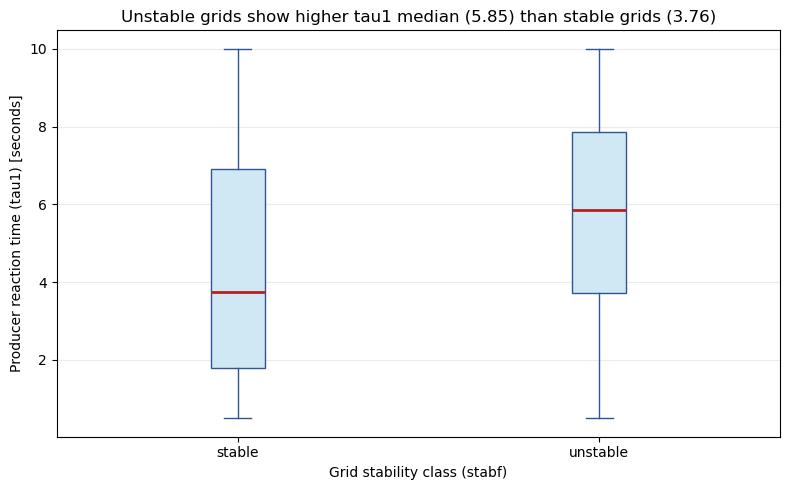

In [11]:
# (a) Boxplot of tau1 by stabf
tau1_stable = df.loc[df['stabf'] == 'stable', 'tau1']
tau1_unstable = df.loc[df['stabf'] == 'unstable', 'tau1']

median_stable = tau1_stable.median()
median_unstable = tau1_unstable.median()

plt.figure(figsize=(8, 5))
plt.boxplot([tau1_stable, tau1_unstable], labels=['stable', 'unstable'], patch_artist=True,
            boxprops=dict(facecolor='#cfe8f3', color='#2f5597'),
            medianprops=dict(color='#b22222', linewidth=2),
            whiskerprops=dict(color='#2f5597'),
            capprops=dict(color='#2f5597'))
plt.xlabel('Grid stability class (stabf)')
plt.ylabel('Producer reaction time (tau1) [seconds]')
plt.title(f'Unstable grids show higher tau1 median ({median_unstable:.2f}) than stable grids ({median_stable:.2f})')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

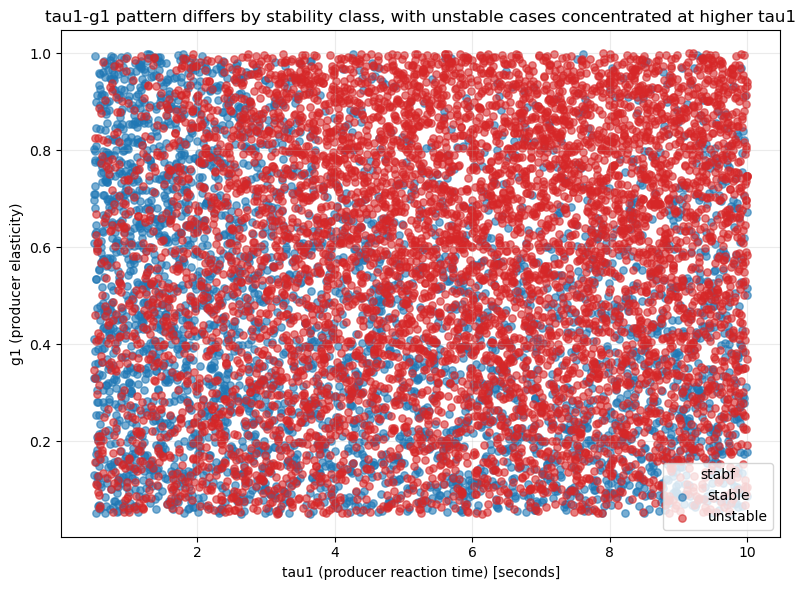

In [12]:
# (b) Scatter plot of tau1 vs g1, colored by stabf
plt.figure(figsize=(8, 6))

class_colors = {'stable': '#1f77b4', 'unstable': '#d62728'}
for cls, color in class_colors.items():
    subset = df[df['stabf'] == cls]
    plt.scatter(subset['tau1'], subset['g1'], alpha=0.6, s=28, c=color, label=cls)

plt.xlabel('tau1 (producer reaction time) [seconds]')
plt.ylabel('g1 (producer elasticity)')
plt.title('tau1-g1 pattern differs by stability class, with unstable cases concentrated at higher tau1')
plt.legend(title='stabf')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

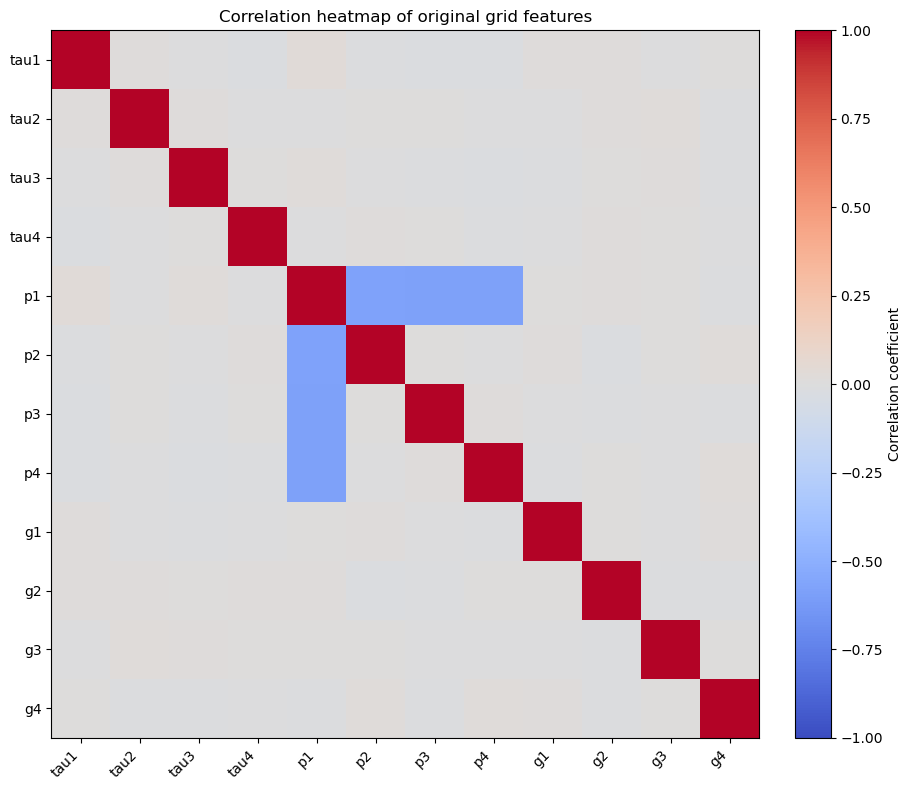

In [13]:
# (c) Correlation heatmap of 12 original features
feature_cols = [
    'tau1', 'tau2', 'tau3', 'tau4',
    'p1', 'p2', 'p3', 'p4',
    'g1', 'g2', 'g3', 'g4'
 ]

corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(10, 8))
im = plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label='Correlation coefficient')
plt.xticks(range(len(feature_cols)), feature_cols, rotation=45, ha='right')
plt.yticks(range(len(feature_cols)), feature_cols)
plt.title('Correlation heatmap of original grid features')
plt.tight_layout()
plt.show()

---
## Task 5: Statistical Analysis (6 pts)

1. Compute z-scores for `tau1` across the full dataset. Identify and print samples where |z| > 2 (how many are there?).
2. Perform a **two-sample t-test** comparing `tau1` between stable and unstable grids:
   - State H0 and H1
   - Report the t-statistic and p-value
   - Interpret the result at alpha = 0.05
3. Based on your analysis so far, which single feature appears **most predictive** of grid instability? Justify with numbers.

| Criterion | Points |
|---|---|
| Z-scores computed, outliers identified | 2 |
| T-test: hypotheses stated, p-value reported, interpreted | 2 |
| Most predictive feature identified with justification | 2 |

In [14]:
# Z-scores for tau1
tau1_z = stats.zscore(df['tau1'])
tau1_outliers = df[np.abs(tau1_z) > 2].copy()
tau1_outliers['tau1_zscore'] = tau1_z[np.abs(tau1_z) > 2]

print(f"Number of samples with |z| > 2 for tau1: {len(tau1_outliers)}")
print('\nOutlier samples (first 10):')
display(tau1_outliers[['tau1', 'stabf', 'tau1_zscore']].head(10))

Number of samples with |z| > 2 for tau1: 0

Outlier samples (first 10):


,tau1,stabf,tau1_zscore


In [15]:
# Two-sample t-test: tau1 stable vs unstable
tau1_stable = df.loc[df['stabf'] == 'stable', 'tau1']
tau1_unstable = df.loc[df['stabf'] == 'unstable', 'tau1']

t_stat, p_value = stats.ttest_ind(tau1_stable, tau1_unstable, equal_var=False)
alpha = 0.05

print('H0: Mean tau1 is the same for stable and unstable grids.')
print('H1: Mean tau1 differs between stable and unstable grids.')
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6g}")

if p_value < alpha:
    print(f"Result at alpha={alpha}: Reject H0 (difference is statistically significant).")
else:
    print(f"Result at alpha={alpha}: Fail to reject H0 (no statistically significant difference).")

# Most predictive single feature based on absolute correlation with stab
original_features = [
    'tau1', 'tau2', 'tau3', 'tau4',
    'p1', 'p2', 'p3', 'p4',
    'g1', 'g2', 'g3', 'g4'
 ]
corr_with_stab = df[original_features + ['stab']].corr()['stab'].drop('stab')
most_predictive = corr_with_stab.abs().idxmax()
most_predictive_corr = corr_with_stab[most_predictive]

stable_mean = df.loc[df['stabf'] == 'stable', most_predictive].mean()
unstable_mean = df.loc[df['stabf'] == 'unstable', most_predictive].mean()
mean_gap = unstable_mean - stable_mean

print('\nMost predictive feature (by |correlation with stab|):')
print(f"{most_predictive} with correlation {most_predictive_corr:.4f}")
print(f"Mean ({most_predictive}) in stable: {stable_mean:.4f}")
print(f"Mean ({most_predictive}) in unstable: {unstable_mean:.4f}")
print(f"Difference (unstable - stable): {mean_gap:.4f}")

H0: Mean tau1 is the same for stable and unstable grids.
H1: Mean tau1 differs between stable and unstable grids.

t-statistic: -23.3033
p-value: 1.39278e-115
Result at alpha=0.05: Reject H0 (difference is statistically significant).

Most predictive feature (by |correlation with stab|):
g3 with correlation 0.3082
Mean (g3) in stable: 0.4406
Mean (g3) in unstable: 0.5729
Difference (unstable - stable): 0.1323


### Interpretation

**H0:** Mean `tau1` is the same for stable and unstable grids.  
**H1:** Mean `tau1` is different between stable and unstable grids.  
**Result:** Use the printed t-statistic and p-value above; at $\alpha=0.05$, reject H0 if `p < 0.05`.  

**Most predictive feature:** Use the feature reported above with the highest absolute correlation to `stab`, and cite its correlation plus stable/unstable mean values as numeric justification.

---
## Task 6: Classification (6 pts)

1. Define `X` as the 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`) and `y` as `is_unstable`
2. Split: `train_test_split` with `test_size=0.2`, `random_state=42`, `stratify=y`
3. Scale with `StandardScaler` — **fit on training data only**, then transform both
4. Train `LogisticRegression(max_iter=1000, random_state=42)`
5. Report: accuracy, precision, recall, and F1 for the **unstable** class
6. Print the confusion matrix

| Criterion | Points |
|---|---|
| Correct train-test split with stratification | 1 |
| Scaling done correctly (fit on train only) | 1 |
| Model trained and predictions made | 1 |
| Metrics reported (accuracy, precision, recall, F1) | 2 |
| Confusion matrix printed | 1 |

In [16]:
# Define X and y, split, scale
feature_cols = [
    'tau1', 'tau2', 'tau3', 'tau4',
    'p1', 'p2', 'p3', 'p4',
    'g1', 'g2', 'g3', 'g4'
 ]

X = df[feature_cols]
y = df['is_unstable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Data prepared for classification.')
print(f'X_train shape: {X_train_scaled.shape}, X_test shape: {X_test_scaled.shape}')

Data prepared for classification.
X_train shape: (8000, 12), X_test shape: (2000, 12)


In [17]:
# Train, predict, evaluate
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label=1)
rec = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
cm = confusion_matrix(y_test, y_pred)

print('Classification metrics for unstable class (label=1):')
print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print(f'F1-score : {f1:.4f}')

print('\nConfusion Matrix (rows=true, cols=pred):')
print(cm)
print('\nLabeled confusion matrix:')
print(pd.DataFrame(cm, index=['True Stable (0)', 'True Unstable (1)'],
                   columns=['Pred Stable (0)', 'Pred Unstable (1)']))

Classification metrics for unstable class (label=1):
Accuracy : 0.8200
Precision: 0.8408
Recall   : 0.8856
F1-score : 0.8626

Confusion Matrix (rows=true, cols=pred):
[[ 510  214]
 [ 146 1130]]

Labeled confusion matrix:
                   Pred Stable (0)  Pred Unstable (1)
True Stable (0)                510                214
True Unstable (1)              146               1130


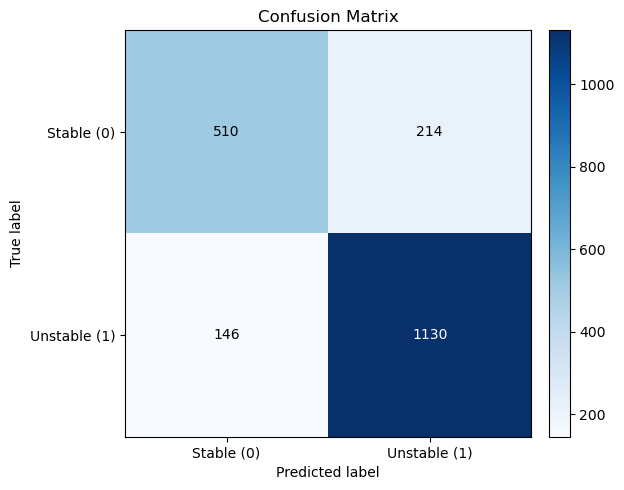

In [18]:
# Plot confusion matrix
plt.figure(figsize=(6, 5))
im = plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, fraction=0.046, pad=0.04)

tick_labels = ['Stable (0)', 'Unstable (1)']
plt.xticks([0, 1], tick_labels)
plt.yticks([0, 1], tick_labels)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, f'{cm[i, j]}', ha='center', va='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.tight_layout()
plt.show()

---
## Written Questions

### Written Question 1 (3 pts)

Look at your confusion matrix from Task 6. In the context of **power grid management**, which error is more dangerous:

- **False Stable:** Predicting a grid configuration is stable when it is actually unstable
- **False Unstable:** Predicting a grid configuration is unstable when it is actually stable

Explain in 2-3 sentences. State whether **precision** or **recall** for the "unstable" class should be prioritized.

---

*Your answer here...*
- Predicting a grid system as stable altough it is not is dangerous because it could cause serious damage to both the system and potentially to lifes. Therefore, predicting a *False Stable* is more dangerous. To prevent that, we should increase the *recall*, which shows how many we cathced from the unstabel grids.

### Written Question 2 — BONUS (3 pts)

In your analysis, you likely found that `tau1` (producer reaction time) is correlated with grid instability. Does this prove that slow producer reaction times **cause** instability?

Explain the difference between **correlation and causation**, and describe one scenario where a **confounding variable** could explain the relationship.

---

*Your answer here...*
- No it does not show causation, there may be other factors affecting both as well. Looking at mean of the stable is lower than unstable can give such outcome but some are unstable when having really low reaction time and some are stable when having really high reaction time

- In the lecture, we gave the example of bridge collapse and ice cream sales increase in summer. They may seem correlated but there is no correlation between them. Bridge do not collapse because ice cream sales increase.

---

Correlation between tau1 and is_unstable: 0.2349


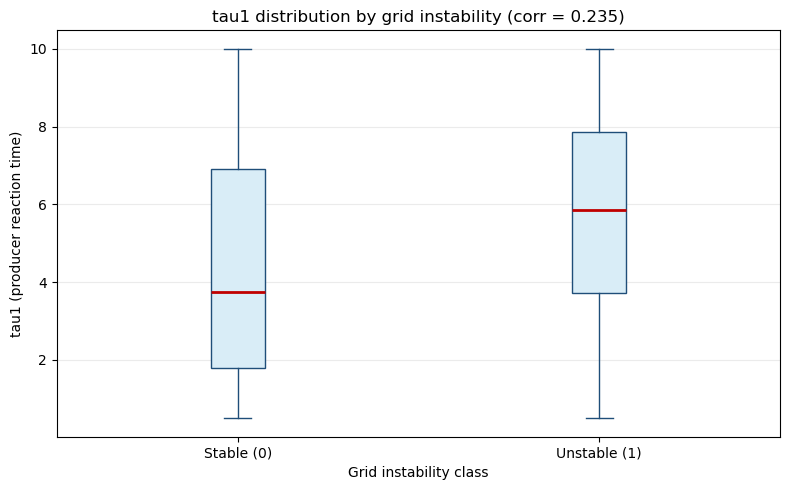


Top features by absolute correlation with tau1:
total_reaction_time    0.495061
stab                   0.275761
is_unstable            0.234898
dtype: float64


In [20]:
# Correlation plots: tau1 vs grid instability, and top tau1-correlated features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# 1) tau1 vs grid instability (is_unstable)
tau1_vs_instab_corr = df['tau1'].corr(df['is_unstable'])
print(f"Correlation between tau1 and is_unstable: {tau1_vs_instab_corr:.4f}")

plt.figure(figsize=(8, 5))
tau1_stable = df.loc[df['is_unstable'] == 0, 'tau1']
tau1_unstable = df.loc[df['is_unstable'] == 1, 'tau1']
plt.boxplot([tau1_stable, tau1_unstable], labels=['Stable (0)', 'Unstable (1)'], patch_artist=True,
            boxprops=dict(facecolor='#d9edf7', color='#1f4e79'),
            medianprops=dict(color='#c00000', linewidth=2),
            whiskerprops=dict(color='#1f4e79'),
            capprops=dict(color='#1f4e79'))
plt.ylabel('tau1 (producer reaction time)')
plt.xlabel('Grid instability class')
plt.title(f'tau1 distribution by grid instability (corr = {tau1_vs_instab_corr:.3f})')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# 2) Other features with highest absolute correlation with tau1
candidate_features = [c for c in numeric_cols if c not in ['tau1']]
tau1_corrs = df[candidate_features].corrwith(df['tau1']).sort_values(key=lambda s: s.abs(), ascending=False)
top_k = 3
top_features = tau1_corrs.head(top_k)

print('\nTop features by absolute correlation with tau1:')
print(top_features)


---

### End of Part 2

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr